In [2]:
import sys
sys.path.insert(0, "..")

In [3]:
import polars as pl
import matplotlib.pyplot as plt

df = pl.scan_parquet("../data/processed/long_by_store/*.parquet")
print("Loaded lazily, schema:")
print(df.collect_schema())

Loaded lazily, schema:
Schema({'id': String, 'item_id': String, 'dept_id': String, 'cat_id': String, 'store_id': String, 'state_id': String, 'd': String, 'sales': Int32, 'date': Date, 'wm_yr_wk': Int64, 'wday': Int8, 'month': Int8, 'year': Int16, 'event_name_1': String, 'event_type_1': String, 'event_name_2': String, 'event_type_2': String, 'snap_CA': Int8, 'snap_TX': Int8, 'snap_WI': Int8, 'sell_price': Float32})


In [3]:
shape = df.select(pl.len()).collect().item()
print(f"Rows: {shape:,}")
print(f"Columns: {df.collect_schema().names()}")
df.head(10).collect()

Rows: 59,181,090
Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price']


id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
str,str,str,str,str,str,str,i32,date,i64,i8,i8,i16,str,str,str,str,i8,i8,i8,f32
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_1""",3,2011-01-29,11101,1,1,2011,"""none""","""none""","""none""","""none""",0,0,0,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_2""",0,2011-01-30,11101,2,1,2011,"""none""","""none""","""none""","""none""",0,0,0,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_3""",0,2011-01-31,11101,3,1,2011,"""none""","""none""","""none""","""none""",0,0,0,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_4""",1,2011-02-01,11101,4,2,2011,"""none""","""none""","""none""","""none""",1,1,0,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_5""",4,2011-02-02,11101,5,2,2011,"""none""","""none""","""none""","""none""",1,0,1,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_6""",2,2011-02-03,11101,6,2,2011,"""none""","""none""","""none""","""none""",1,1,1,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_7""",0,2011-02-04,11101,7,2,2011,"""none""","""none""","""none""","""none""",1,0,0,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_8""",2,2011-02-05,11102,1,2,2011,"""none""","""none""","""none""","""none""",1,1,1,2.0
"""FOODS_1_001_CA_1_evaluation""","""FOODS_1_001""","""FOODS_1""","""FOODS""","""CA_1""","""CA""","""d_9""",0,2011-02-06,11102,2,2,2011,"""SuperBowl""","""Sporting""","""none""","""none""",1,1,1,2.0


In [4]:
df.select("sales").collect().describe()

statistic,sales
str,f64
"""count""",5.918109e7
"""null_count""",0.0
"""mean""",1.130888
"""std""",3.870038
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",1.0
"""max""",763.0


In [5]:
date_range = df.select([
    pl.col("date").min().alias("min_date"),
    pl.col("date").max().alias("max_date"),
    pl.col("date").n_unique().alias("unique_days"),
    pl.col("store_id").n_unique().alias("unique_stores"),
    pl.col("item_id").n_unique().alias("unique_items"),
    pl.len().alias("total_rows"),
]).collect()

print(date_range)

shape: (1, 6)
┌────────────┬────────────┬─────────────┬───────────────┬──────────────┬────────────┐
│ min_date   ┆ max_date   ┆ unique_days ┆ unique_stores ┆ unique_items ┆ total_rows │
│ ---        ┆ ---        ┆ ---         ┆ ---           ┆ ---          ┆ ---        │
│ date       ┆ date       ┆ u32         ┆ u32           ┆ u32          ┆ u32        │
╞════════════╪════════════╪═════════════╪═══════════════╪══════════════╪════════════╡
│ 2011-01-29 ┆ 2016-05-22 ┆ 1941        ┆ 10            ┆ 3049         ┆ 59181090   │
└────────────┴────────────┴─────────────┴───────────────┴──────────────┴────────────┘


In [6]:
zero_rate = df.select(
    (pl.col("sales") == 0).sum().alias("zero_days"),
    pl.len().alias("total_days"),
).collect()

zeros = zero_rate["zero_days"][0]
total = zero_rate["total_days"][0]
print(f"Zero sales days: {zeros:,} / {total:,} ({zeros/total*100:.1f}%)")

Zero sales days: 40,241,819 / 59,181,090 (68.0%)


shape: (3, 4)
┌───────────┬───────────┬────────────┬───────────┐
│ cat_id    ┆ zero_rate ┆ mean_sales ┆ max_sales │
│ ---       ┆ ---       ┆ ---        ┆ ---       │
│ str       ┆ f64       ┆ f64        ┆ i32       │
╞═══════════╪═══════════╪════════════╪═══════════╡
│ FOODS     ┆ 0.617734  ┆ 1.646427   ┆ 763       │
│ HOUSEHOLD ┆ 0.716022  ┆ 0.726498   ┆ 626       │
│ HOBBIES   ┆ 0.771492  ┆ 0.569058   ┆ 294       │
└───────────┴───────────┴────────────┴───────────┘


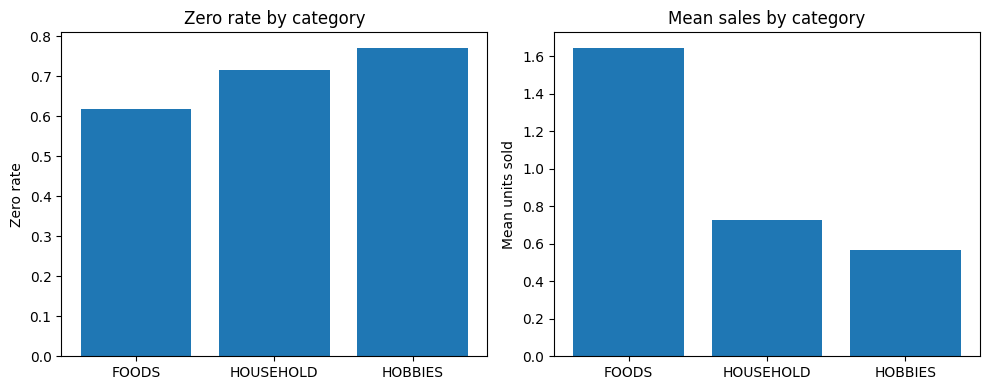

In [7]:
cat_stats = df.group_by("cat_id").agg([
    (pl.col("sales") == 0).mean().alias("zero_rate"),
    pl.col("sales").mean().alias("mean_sales"),
    pl.col("sales").max().alias("max_sales"),
]).sort("zero_rate").collect()

print(cat_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(cat_stats["cat_id"], cat_stats["zero_rate"])
axes[0].set_title("Zero rate by category")
axes[0].set_ylabel("Zero rate")
axes[1].bar(cat_stats["cat_id"], cat_stats["mean_sales"])
axes[1].set_title("Mean sales by category")
axes[1].set_ylabel("Mean units sold")
plt.tight_layout()
plt.show()

shape: (7, 2)
┌──────┬────────────┐
│ wday ┆ mean_sales │
│ ---  ┆ ---        │
│ i8   ┆ f64        │
╞══════╪════════════╡
│ 1    ┆ 1.367867   │
│ 2    ┆ 1.354675   │
│ 3    ┆ 1.082156   │
│ 4    ┆ 1.000344   │
│ 5    ┆ 0.988207   │
│ 6    ┆ 0.994459   │
│ 7    ┆ 1.126844   │
└──────┴────────────┘


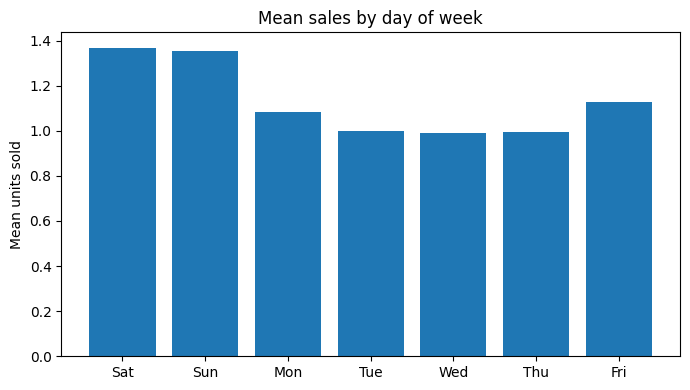

In [8]:
wday_stats = df.group_by("wday").agg(
    pl.col("sales").mean().alias("mean_sales"),
).sort("wday").collect()

print(wday_stats)

wday_labels = ["Sat", "Sun", "Mon", "Tue", "Wed", "Thu", "Fri"]
plt.figure(figsize=(7, 4))
plt.bar(wday_labels, wday_stats["mean_sales"])
plt.title("Mean sales by day of week")
plt.ylabel("Mean units sold")
plt.tight_layout()
plt.show()

shape: (12, 2)
┌───────┬────────────┐
│ month ┆ mean_sales │
│ ---   ┆ ---        │
│ i8    ┆ f64        │
╞═══════╪════════════╡
│ 1     ┆ 1.109621   │
│ 2     ┆ 1.136262   │
│ 3     ┆ 1.126266   │
│ 4     ┆ 1.129294   │
│ 5     ┆ 1.117914   │
│ 6     ┆ 1.147964   │
│ 7     ┆ 1.151932   │
│ 8     ┆ 1.178965   │
│ 9     ┆ 1.163636   │
│ 10    ┆ 1.13852    │
│ 11    ┆ 1.091861   │
│ 12    ┆ 1.081681   │
└───────┴────────────┘


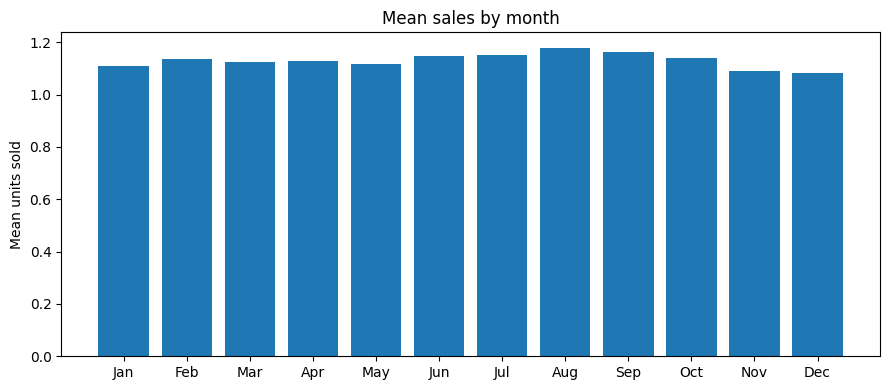

In [9]:
month_stats = df.group_by("month").agg(
    pl.col("sales").mean().alias("mean_sales"),
).sort("month").collect()

with pl.Config(tbl_rows=12):
    print(month_stats)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(9, 4))
plt.bar(month_labels, month_stats["mean_sales"])
plt.title("Mean sales by month")
plt.ylabel("Mean units sold")
plt.tight_layout()
plt.show()

shape: (5, 3)
┌──────────────┬────────────┬──────────┐
│ event_type_1 ┆ mean_sales ┆ days     │
│ ---          ┆ ---        ┆ ---      │
│ str          ┆ f64        ┆ u32      │
╞══════════════╪════════════╪══════════╡
│ Sporting     ┆ 1.174026   ┆ 487840   │
│ Cultural     ┆ 1.138688   ┆ 1128130  │
│ none         ┆ 1.135105   ┆ 54363670 │
│ Religious    ┆ 1.129099   ┆ 1646460  │
│ National     ┆ 0.96617    ┆ 1554990  │
└──────────────┴────────────┴──────────┘


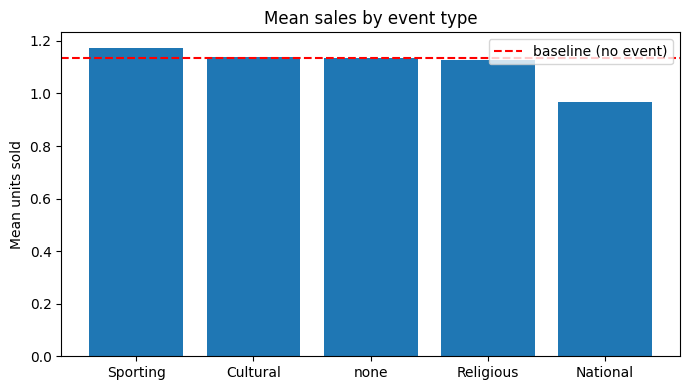

In [10]:
event_stats = df.group_by("event_type_1").agg(
    pl.col("sales").mean().alias("mean_sales"),
    pl.len().alias("days"),
).sort("mean_sales", descending=True).collect()

print(event_stats)

plt.figure(figsize=(7, 4))
plt.bar(event_stats["event_type_1"], event_stats["mean_sales"])
plt.axhline(y=event_stats.filter(pl.col("event_type_1") == "none")["mean_sales"][0],
            color="red", linestyle="--", label="baseline (no event)")
plt.title("Mean sales by event type")
plt.ylabel("Mean units sold")
plt.legend()
plt.tight_layout()
plt.show()

shape: (2, 3)
┌──────┬────────────┬──────────┐
│ snap ┆ mean_sales ┆ days     │
│ ---  ┆ ---        ┆ ---      │
│ i8   ┆ f64        ┆ u32      │
╞══════╪════════════╪══════════╡
│ 0    ┆ 1.085408   ┆ 39667490 │
│ 1    ┆ 1.223339   ┆ 19513600 │
└──────┴────────────┴──────────┘
SNAP lift: 12.7%


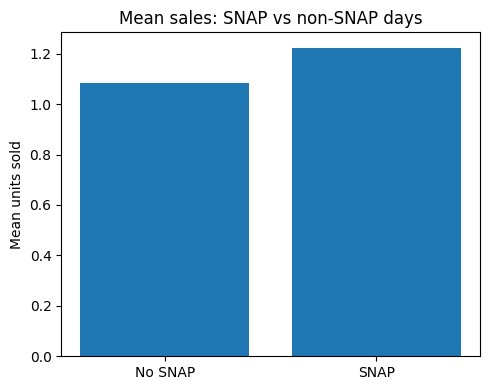

In [11]:
snap_df = df.with_columns(
    pl.when(pl.col("state_id") == "CA").then(pl.col("snap_CA"))
    .when(pl.col("state_id") == "TX").then(pl.col("snap_TX"))
    .when(pl.col("state_id") == "WI").then(pl.col("snap_WI"))
    .otherwise(0)
    .alias("snap")
)

snap_stats = snap_df.group_by("snap").agg(
    pl.col("sales").mean().alias("mean_sales"),
    pl.len().alias("days"),
).sort("snap").collect()

print(snap_stats)
snap_lift = (snap_stats["mean_sales"][1] - snap_stats["mean_sales"][0]) / snap_stats["mean_sales"][0]
print(f"SNAP lift: {snap_lift*100:.1f}%")

plt.figure(figsize=(5, 4))
plt.bar(["No SNAP", "SNAP"], snap_stats["mean_sales"])
plt.title("Mean sales: SNAP vs non-SNAP days")
plt.ylabel("Mean units sold")
plt.tight_layout()
plt.show()

shape: (3, 5)
┌───────────┬────────────┬───────────┬───────────┬───────────┐
│ cat_id    ┆ mean_price ┆ std_price ┆ min_price ┆ max_price │
│ ---       ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│ str       ┆ f32        ┆ f32       ┆ f32       ┆ f32       │
╞═══════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ FOODS     ┆ 3.24895    ┆ 2.130764  ┆ 0.01      ┆ 19.48     │
│ HOBBIES   ┆ 5.329613   ┆ 4.821907  ┆ 0.01      ┆ 30.98     │
│ HOUSEHOLD ┆ 5.465684   ┆ 3.373758  ┆ 0.01      ┆ 107.32    │
└───────────┴────────────┴───────────┴───────────┴───────────┘


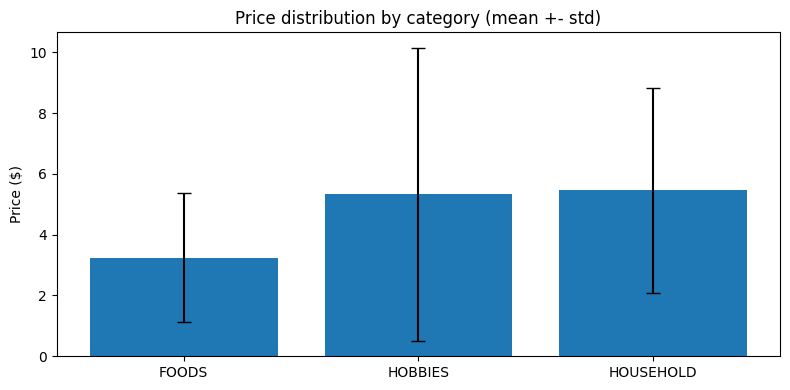

In [ ]:
price_stats = df.filter(pl.col("sell_price").is_not_null()).group_by("cat_id").agg(
    pl.col("sell_price").mean().alias("mean_price"),
    pl.col("sell_price").std().alias("std_price"),
    pl.col("sell_price").min().alias("min_price"),
    pl.col("sell_price").max().alias("max_price"),
).sort("cat_id").collect()

print(price_stats)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(price_stats))
ax.bar(x, price_stats["mean_price"], yerr=price_stats["std_price"],
       capsize=5, label="mean +- std")
ax.set_xticks(x)
ax.set_xticklabels(price_stats["cat_id"])
ax.set_title("Price distribution by category (mean +- std)")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

shape: (7, 3)
┌───────────┬─────────────┬──────────────┐
│ cat_id    ┆ dept_id     ┆ unique_items │
│ ---       ┆ ---         ┆ ---          │
│ str       ┆ str         ┆ u32          │
╞═══════════╪═════════════╪══════════════╡
│ FOODS     ┆ FOODS_1     ┆ 216          │
│ FOODS     ┆ FOODS_2     ┆ 398          │
│ FOODS     ┆ FOODS_3     ┆ 823          │
│ HOBBIES   ┆ HOBBIES_1   ┆ 416          │
│ HOBBIES   ┆ HOBBIES_2   ┆ 149          │
│ HOUSEHOLD ┆ HOUSEHOLD_1 ┆ 532          │
│ HOUSEHOLD ┆ HOUSEHOLD_2 ┆ 515          │
└───────────┴─────────────┴──────────────┘
Total unique item:          3049


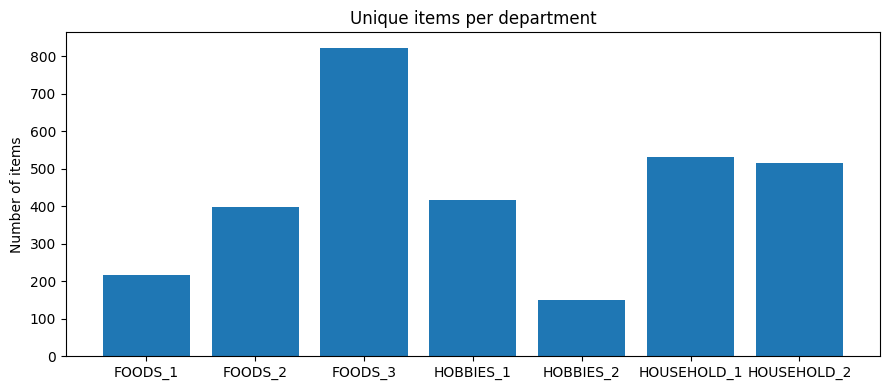

In [13]:
item_counts = df.group_by(["cat_id", "dept_id"]).agg(
    pl.col("item_id").n_unique().alias("unique_items")
).sort(["cat_id", "dept_id"]).collect()

print(item_counts)
print(f"Total unique item:          {item_counts['unique_items'].sum()}")

plt.figure(figsize=(9, 4))
plt.bar(item_counts["dept_id"], item_counts["unique_items"])
plt.title("Unique items per department")
plt.ylabel("Number of items")
plt.tight_layout()
plt.show()

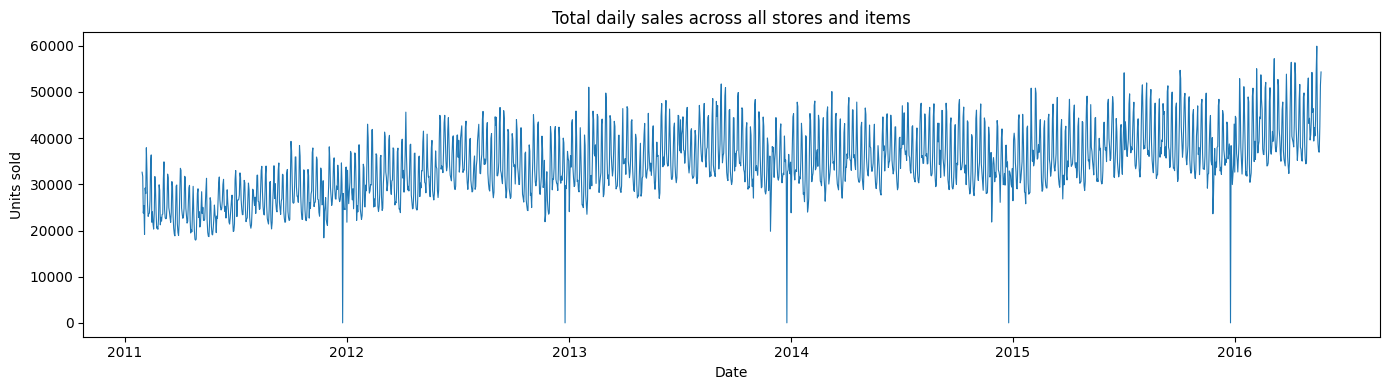

In [14]:
daily = df.group_by("date").agg(
    pl.col("sales").sum().alias("total_sales")
).sort("date").collect()

plt.figure(figsize=(14, 4))
plt.plot(daily["date"].to_list(), daily["total_sales"].to_list(), linewidth=0.8)
plt.title("Total daily sales across all stores and items")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [15]:
print(f"Min total sales: {daily['total_sales'].min()}")
print(f"Max total sales: {daily['total_sales'].max()}")
print(f"Mean total sales: {daily['total_sales'].mean():.1f}")
print(f"Std total sales: {daily['total_sales'].std():.1f}")
print("\nLowest 10 days:")
print(daily.sort("total_sales").head(10))
print("\nHighest 10 days:")
print(daily.sort("total_sales", descending=True).head(10))

Min total sales: 11
Max total sales: 59921
Mean total sales: 34480.8
Std total sales: 7425.9

Lowest 10 days:
shape: (10, 2)
┌────────────┬─────────────┐
│ date       ┆ total_sales │
│ ---        ┆ ---         │
│ date       ┆ i32         │
╞════════════╪═════════════╡
│ 2012-12-25 ┆ 11          │
│ 2011-12-25 ┆ 13          │
│ 2015-12-25 ┆ 14          │
│ 2013-12-25 ┆ 20          │
│ 2014-12-25 ┆ 20          │
│ 2011-04-27 ┆ 17929       │
│ 2011-04-26 ┆ 18113       │
│ 2011-04-28 ┆ 18145       │
│ 2011-11-24 ┆ 18427       │
│ 2011-05-19 ┆ 18684       │
└────────────┴─────────────┘

Highest 10 days:
shape: (10, 2)
┌────────────┬─────────────┐
│ date       ┆ total_sales │
│ ---        ┆ ---         │
│ date       ┆ i32         │
╞════════════╪═════════════╡
│ 2016-05-15 ┆ 59921       │
│ 2016-03-06 ┆ 57218       │
│ 2016-04-03 ┆ 56425       │
│ 2016-04-09 ┆ 56340       │
│ 2016-02-06 ┆ 55040       │
│ 2015-10-03 ┆ 54687       │
│ 2016-05-22 ┆ 54338       │
│ 2016-05-14 ┆ 54308       │
│

In [16]:
daily.sort("total_sales").head(10)

date,total_sales
date,i32
2012-12-25,11
2011-12-25,13
2015-12-25,14
2013-12-25,20
2014-12-25,20
2011-04-27,17929
2011-04-26,18113
2011-04-28,18145
2011-11-24,18427


shape: (6, 3)
┌──────┬─────────────┬────────────┐
│ year ┆ total_sales ┆ mean_sales │
│ ---  ┆ ---         ┆ ---        │
│ i16  ┆ i32         ┆ f64        │
╞══════╪═════════════╪════════════╡
│ 2011 ┆ 8856585     ┆ 0.861944   │
│ 2012 ┆ 12061837    ┆ 1.080874   │
│ 2013 ┆ 13135753    ┆ 1.180333   │
│ 2014 ┆ 13089776    ┆ 1.176202   │
│ 2015 ┆ 13800811    ┆ 1.240093   │
│ 2016 ┆ 5982411     ┆ 1.372091   │
└──────┴─────────────┴────────────┘


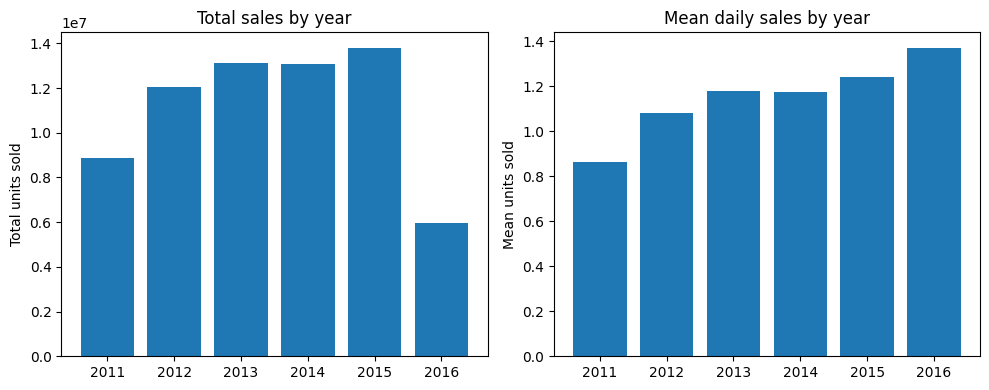

In [17]:
year_stats = df.group_by("year").agg(
    pl.col("sales").sum().alias("total_sales"),
    pl.col("sales").mean().alias("mean_sales"),
).sort("year").collect()

print(year_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(year_stats["year"].cast(str).to_list(), year_stats["total_sales"])
axes[0].set_title("Total sales by year")
axes[0].set_ylabel("Total units sold")
axes[1].bar(year_stats["year"].cast(str).to_list(), year_stats["mean_sales"])
axes[1].set_title("Mean daily sales by year")
axes[1].set_ylabel("Mean units sold")
plt.tight_layout()
plt.show()

In [18]:
# get the highest selling item across all stores
top_item = (
    df.group_by("item_id").agg(pl.col("sales").sum().alias("total"))
    .sort("total", descending=True)
    .head(1)
    .collect()["item_id"][0]
)

# get a highly intermittent item (high zero rate)
intermittent_item = (
    df.group_by("item_id").agg(
        (pl.col("sales") == 0).mean().alias("zero_rate")
    )
    .sort("zero_rate", descending=True)
    .head(1)
    .collect()["item_id"][0]
)

print(f"Top volume item: {top_item}")
print(f"Most intermittent item: {intermittent_item}")

Top volume item: FOODS_3_090
Most intermittent item: HOUSEHOLD_2_101


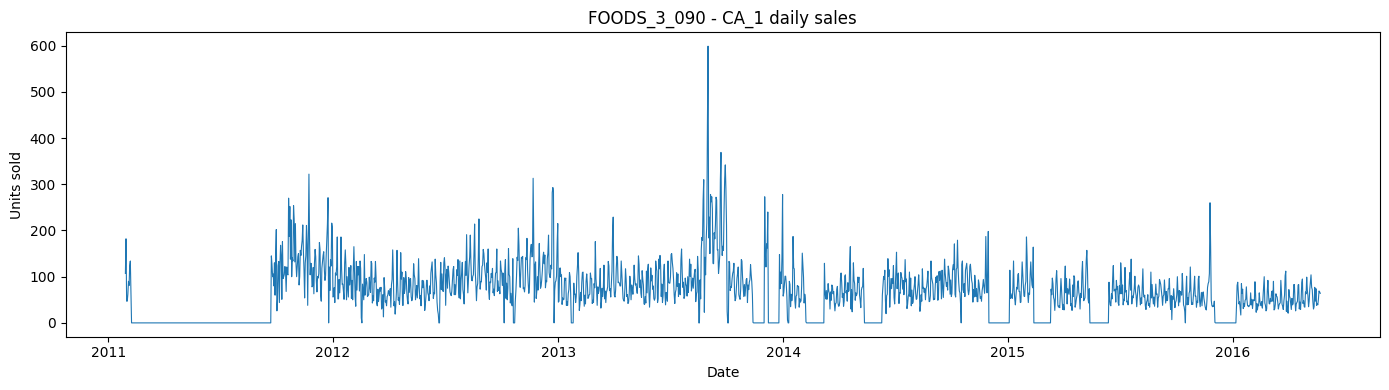

In [19]:
top_series = (
    df.filter(
        (pl.col("item_id") == top_item) & (pl.col("store_id") == "CA_1")
    )
    .select(["date", "sales"])
    .sort("date")
    .collect()
)

plt.figure(figsize=(14, 4))
plt.plot(top_series["date"].to_list(), top_series["sales"].to_list(), linewidth=0.8)
plt.title(f"{top_item} - CA_1 daily sales")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [20]:
print(f"Zero rate: {(top_series['sales'] == 0).mean():.3f}")
print(f"Mean sales: {top_series['sales'].mean():.2f}")
print(f"Std sales: {top_series['sales'].std():.2f}")
print(f"Max sales: {top_series['sales'].max()}")
print("\nSales on zero days context - dates with 0 sales:")
with pl.Config(tbl_rows=20):
    print(top_series.filter(pl.col("sales") == 0).tail(20))

Zero rate: 0.242
Mean sales: 66.39
Std sales: 57.50
Max sales: 599

Sales on zero days context - dates with 0 sales:
shape: (20, 2)
┌────────────┬───────┐
│ date       ┆ sales │
│ ---        ┆ ---   │
│ date       ┆ i32   │
╞════════════╪═══════╡
│ 2015-12-18 ┆ 0     │
│ 2015-12-19 ┆ 0     │
│ 2015-12-20 ┆ 0     │
│ 2015-12-21 ┆ 0     │
│ 2015-12-22 ┆ 0     │
│ 2015-12-23 ┆ 0     │
│ 2015-12-24 ┆ 0     │
│ 2015-12-25 ┆ 0     │
│ 2015-12-26 ┆ 0     │
│ 2015-12-27 ┆ 0     │
│ 2015-12-28 ┆ 0     │
│ 2015-12-29 ┆ 0     │
│ 2015-12-30 ┆ 0     │
│ 2015-12-31 ┆ 0     │
│ 2016-01-01 ┆ 0     │
│ 2016-01-02 ┆ 0     │
│ 2016-01-03 ┆ 0     │
│ 2016-01-04 ┆ 0     │
│ 2016-01-05 ┆ 0     │
│ 2016-01-06 ┆ 0     │
└────────────┴───────┘


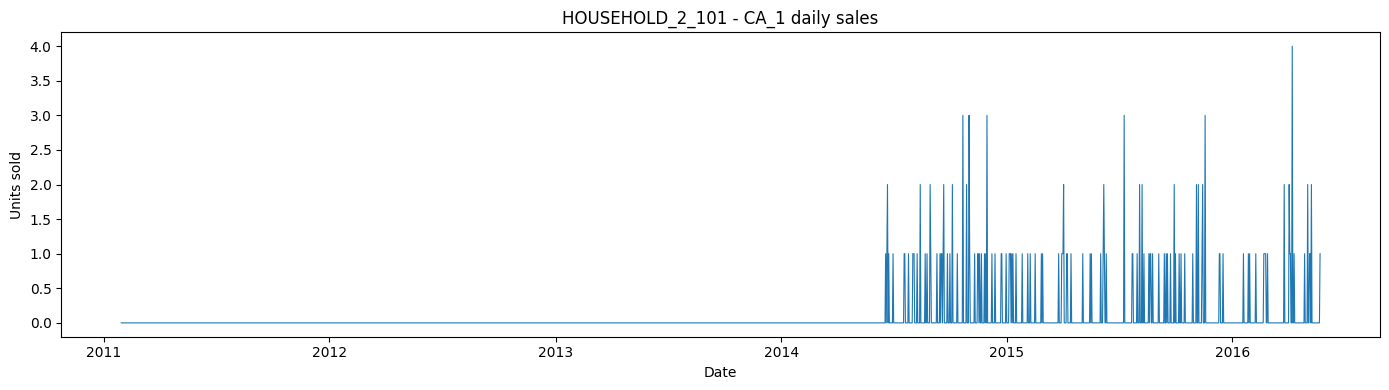

In [21]:
intermittent_series = (
    df.filter(
        (pl.col("item_id") == intermittent_item) & (pl.col("store_id") == "CA_1")
    )
    .select(["date", "sales"])
    .sort("date")
    .collect()
)

plt.figure(figsize=(14, 4))
plt.plot(intermittent_series["date"].to_list(), intermittent_series["sales"].to_list(), linewidth=0.8)
plt.title(f"{intermittent_item} - CA_1 daily sales")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [22]:
print(f"Zero rate: {(intermittent_series['sales'] == 0).mean():.3f}")
print(f"Mean sales: {intermittent_series['sales'].mean():.2f}")
print(f"Std sales: {intermittent_series['sales'].std():.2f}")
print(f"Max sales: {intermittent_series['sales'].max()}")
print(f"Days with non-zero sales: {(intermittent_series['sales'] > 0).sum()}")
print("\nNon-zero sales distribution:")
print(intermittent_series.filter(pl.col("sales") > 0)["sales"].describe())

Zero rate: 0.937
Mean sales: 0.08
Std sales: 0.34
Max sales: 4
Days with non-zero sales: 123

Non-zero sales distribution:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 123.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 1.252033 │
│ std        ┆ 0.566749 │
│ min        ┆ 1.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 1.0      │
│ max        ┆ 4.0      │
└────────────┴──────────┘


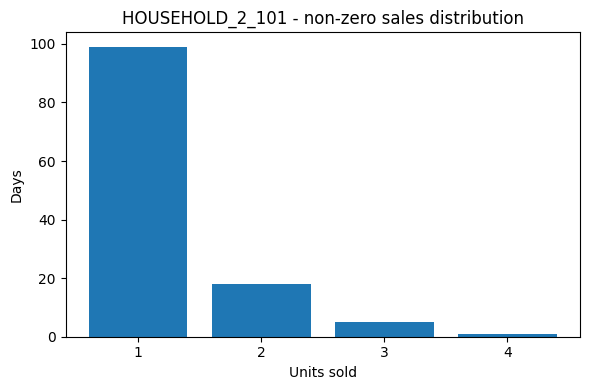

In [23]:
nonzero = intermittent_series.filter(pl.col("sales") > 0)["sales"].to_list()
plt.figure(figsize=(6, 4))
plt.hist(nonzero, bins=range(1, intermittent_series["sales"].max() + 2), align="left", rwidth=0.8)
plt.title(f"{intermittent_item} - non-zero sales distribution")
plt.xlabel("Units sold")
plt.ylabel("Days")
plt.xticks(range(1, intermittent_series["sales"].max() + 1))
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

single_item = (
    df.filter(
        (pl.col("item_id") == "FOODS_3_090") & (pl.col("store_id") == "CA_1")
    )
    .select(["date", "sales", "month"])
    .sort("date")
    .collect()
)

sales = single_item["sales"].to_list()

season_map = {12: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3}
season = single_item["month"].replace_strict(season_map).to_list()
month = single_item["month"].to_list()

# lag correlations
for lag in [1, 2, 3, 7, 14, 28, 364]:
    corr = np.corrcoef(sales[lag:], sales[:-lag])[0, 1]
    print(f"lag_{lag} correlation:      {corr:.3f}")

# calendar correlations
month_corr = np.corrcoef(sales, month)[0, 1]
season_corr = np.corrcoef(sales, season)[0, 1]
print(f"month correlation:      {month_corr:.3f}")
print(f"season correlation:     {season_corr:.3f}")

lag_1 correlation:      0.729
lag_2 correlation:      0.575
lag_3 correlation:      0.496
lag_7 correlation:      0.625
lag_14 correlation:      0.521
lag_28 correlation:      0.422
lag_364 correlation:      0.241
month correlation:      0.202
season correlation:     0.220


In [5]:
season_stats = df.with_columns(
    pl.when(pl.col("month").is_in([12, 1, 2])).then(pl.lit("winter"))
    .when(pl.col("month").is_in([3, 4, 5])).then(pl.lit("spring"))
    .when(pl.col("month").is_in([6, 7, 8])).then(pl.lit("summer"))
    .otherwise(pl.lit("fall"))
    .alias("season")
).group_by("season").agg(
    pl.col("sales").mean().alias("mean_sales"),
    pl.col("sales").std().alias("std_sales"),
).sort("mean_sales", descending=True).collect()

print(season_stats)

shape: (4, 3)
┌────────┬────────────┬───────────┐
│ season ┆ mean_sales ┆ std_sales │
│ ---    ┆ ---        ┆ ---       │
│ str    ┆ f64        ┆ f64       │
╞════════╪════════════╪═══════════╡
│ summer ┆ 1.159747   ┆ 4.102456  │
│ fall   ┆ 1.131418   ┆ 3.940044  │
│ spring ┆ 1.124547   ┆ 3.658094  │
│ winter ┆ 1.110032   ┆ 3.80656   │
└────────┴────────────┴───────────┘


## EDA Summary

### Dataset Overview
- **59.18M rows** across 10 stores, 3,049 unique items, 1,941 days (2011-01-29 to 2016-05-22)
- **3 categories**: FOODS (7 depts), HOBBIES (2 depts), HOUSEHOLD (2 depts)
- **7 departments**, ranging from 149 (HOBBIES_2) to 823 (FOODS_3) unique items

### Demand Characteristics
- **68% of all observations are zero**, heavily intermittent demand across the board
- Zero rates by category: FOODS (62%), HOUSEHOLD (72%), HOBBIES (77%)
- Demand ranges from high-volume/volatile (FOODS_3_090: mean 66 units/day) to near-pure intermittent (HOUSEHOLD_2_101: 93.7% zeros, sells ~1 unit every ~12 days (1/0.08 = 12.5))
- **Zeros do not always mean zero demand**, stockouts are indistinguishable from no-demand periods (e.g. FOODS_3_090 CA_1 shows 3+ week zero runs mid-series)

### Seasonality
- **Strong weekly seasonality**: Saturday/Sunday ~35% above midweek trough (wday 1-2 avg ~1.36 vs wday 4-6 avg ~1.00, (1.36-1.00)/1.00 = 36%): `wday` will be a top feature
- **Weak monthly seasonality**: summer slight peak (Aug: 1.18), winter slight trough (Dec: 1.08), range of only +-5% around mean ((1.18-1.08)/1.13 = 8.8%, effectively +-4.4%)
- **Non-stationary trend**: mean sales roughly doubled from 2011 (0.86) to 2016 (1.37) ((1.37-0.86)/0.86 = +59%), long-window rolling features and trend components are necessary
- **Season (winter/spring/summer/fall)** tested but discarded, correlation with sales (0.220) is nearly identical to month (0.202) with a range of only 0.05 between seasons. `month` subsumes all seasonal signal.

### External Signals
- **SNAP is the strongest external signal**: +13% lift on SNAP-eligible days vs non-SNAP days ((1.223-1.085)/1.085 = 12.7%)
- **Events have mixed impact**: Sporting/Cultural slightly positive, National holidays suppress sales (-15% vs baseline: (0.966-1.135)/1.135 = -14.9%). Christmas causes near-complete closure (11-20 total units across all stores)
- **April 2011 anomaly**: abnormally low sales April 26-28 2011, consistent with the 2011 Super Outbreak tornado disruption

### Pricing
- FOODS: mean $3.25, range $0.01-$19.48
- HOBBIES: mean $5.33, range $0.01-$30.98  
- HOUSEHOLD: mean $5.47, range $0.01-$107.32 (large variance suggests mixed product types)
- **12.3M null prices (~20%)** for items not yet introduced in early periods (12,299,413/59,181,090 = 20.8%), may require forward-fill during feature engineering

### Autocorrelation (FOODS_3_090, CA_1)
- `lag_1`: 0.729, strongest single predictor
- `lag_2`: 0.575
- `lag_3`: 0.496
- `lag_7`: 0.625, weekly seasonality creates a bump above lag_2 and lag_3
- `lag_14`: 0.521
- `lag_28`: 0.422
- `lag_364`: 0.241, yearly signal exists but skipped due to null overhead (1 year of nulls per series)
- `month`: 0.202, `season`: 0.220, nearly identical, season adds nothing over month

### Feature Engineering Implications
| Signal | Strength | Notes |
|---|---|---|
| `wday` | Strong | Must-have, clear weekly pattern |
| `snap` (state-matched) | Strong | +13% lift, use state-specific flag |
| Lag features (7, 28 days) | Strong | Core temporal signal |
| Rolling means | Strong | Especially long windows for trend |
| `days_since_last_sale` | Important | Distinguishes stockout from low demand |
| `month` | Weak | Include but low expected importance |
| Event indicators | Moderate | National holidays need special treatment |
| Price features | Moderate | Price delta and relative price useful |
| Christmas indicator | Special | Extreme outlier, explicit flag needed |